# 02 · Fraud modelling and credibility checks

**Decision:** whether to refer an initiated TRANSFER or CASH_OUT for review or additional authentication.
The original experiment used amount, type and opening origin balance, trained on steps 1–323 and selected its model
and threshold on steps 324–377. Its test window, steps 378–743, **has already been inspected**.

This notebook separates two kinds of evidence:

1. **Fixed historical result:** reproduce the original candidate comparison and frozen policy, without changing its
   features, settings, split or threshold. This is reproducibility evidence, not another independent test.
2. **Development diagnostics:** feature ablation and three rolling temporal checks, all at steps **≤377**.
   These experiments cannot replace the frozen policy or receive a test score here.

**Material provenance limitation:** the [publisher](https://www.kaggle.com/datasets/ealaxi/paysim1/data) warns that cancellation
behaviour affects the balance fields, including opening balances. The original model's pre-transaction interpretation is
therefore conditional and unverified. Excluding closing balances prevents direct post-transaction leakage in code; it does
not establish that the recorded opening balance is free of outcome-dependent simulation artefacts. Amount-and-type-only
experiments provide a more conservative development comparison.

In [1]:
import json
from time import perf_counter
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown
from sklearn.metrics import precision_recall_curve, confusion_matrix, ConfusionMatrixDisplay
from fraud_utils import (ROOT, DATA_PATH, RAW_FEATURES, FEATURE_SETS, ARTIFACTS, prepare_outputs,
                         file_sha256, load_risk_data, features_for, make_model, fit_model,
                         score_model, metrics, choose_threshold, time_windows, save_table, save_figure)

prepare_outputs()
pd.set_option('display.max_columns', 20)
plt.rcParams.update({'figure.figsize': (10, 4.5), 'axes.grid': True, 'grid.alpha': 0.2})
frozen = json.loads((ROOT / 'config' / 'frozen_policy.json').read_text())
assert file_sha256(DATA_PATH) == frozen['data_sha256'], 'Different data: investigate rather than silently redefining the experiment.'
risk = load_risk_data()
train, validation, historical_test = time_windows(risk, [0, 323, 377, 743])
assert frozen['train_end_step'] == 323 and frozen['validation_end_step'] == 377
assert len(train) + len(validation) + len(historical_test) == len(risk)
development = risk.loc[risk.step.le(377)].copy()
assert development.step.max() < historical_test.step.min()

split_summary = pd.DataFrame([
    {'window': name, 'first_step': int(frame.step.min()), 'last_step': int(frame.step.max()),
     'transactions': len(frame), 'fraud_count': int(frame.isFraud.sum()), 'fraud_prevalence': frame.isFraud.mean()}
    for name, frame in [('Original train', train), ('Original validation', validation),
                        ('Previously inspected historical test', historical_test)]
])
save_table(split_summary, 'model_time_windows')
display(split_summary)

,window,first_step,last_step,transactions,fraud_count,fraud_prevalence
0,Original train,1,323,1951895,3643,0.001866
1,Original validation,324,377,410437,560,0.001364
2,Previously inspected historical test,378,743,408077,4010,0.009827


## Original protocol and leakage audit

The time boundaries above are preserved from the original whole-step split at approximately 70% and 85% cumulative
eligible volume. The historical-test labels are now shown openly because this window is no longer sealed.
No random stratification, resampling or cross-window preprocessing is used. Labels are assumed known for training;
actual confirmation delays are unavailable.

| Input | Treatment |
|---|---|
| Type, requested amount | Initiation-time inputs. |
| Opening origin balance and deterministic amount/balance relationships | Original policy retained, with the publisher's warning; removed in the conservative ablation. |
| Opening destination balance | Excluded: availability and provenance are not established. |
| Closing balances and all balance-error residuals | Excluded at ingestion and from feature construction. |
| Account identifiers, `isFlaggedFraud`, `step`, `isFraud` | Never passed to the feature constructor. Step is used only for windows/reporting; `isFraud` is the target. |

The shared feature constructor rejects unexpected columns. Pipelines fit scaling and encoding on training rows only.
Class weights are calculated from training labels. Gradient boosting uses a fixed 150 iterations with automatic random
holdout early stopping disabled. Score ≥ threshold is the alert rule everywhere. The 0.01 full-balance tolerance and
one-unit ratio offset are preserved modelling conventions, in dataset currency units.

Precision measures the fraud share of alerts; recall measures the share of labelled fraud detected; F1 balances them.
AP is non-interpolated average precision, our PR-AUC summary, with prevalence as a no-skill reference. Accuracy is omitted.
Weighted scores are not calibrated probabilities. Undefined rates are displayed as missing, not zero.

In [2]:
# A direct check that the historical feature calculations remain unchanged.
X_train = features_for(train)
X_validation = features_for(validation)
assert list(X_train) == FEATURE_SETS['full']
assert not set(X_train).intersection({'isFraud', 'isFlaggedFraud', 'step', 'newbalanceOrig', 'newbalanceDest'})
assert np.allclose(X_train.log_amount_to_balance, np.log1p(train.amount / (train.oldbalanceOrg + 1.0)))

candidate_specs = [
    ('Logistic Regression (balanced)', 'logistic'),
    ('Histogram GB (ordinary)', 'hgb'),
    ('Histogram GB (balanced)', 'hgb_balanced'),
]
candidates, validation_scores, candidate_rows = {}, {}, []
for name, kind in candidate_specs:
    start = perf_counter()
    model = fit_model(make_model(kind), X_train, train.isFraud)
    scores = score_model(model, validation)
    candidates[name], validation_scores[name] = model, scores
    candidate_rows.append({'model': name, **metrics(validation.isFraud, scores, 0.5),
                           'fit_and_score_seconds': perf_counter() - start})
    print(f'Completed original candidate: {name}')
candidate_results = pd.DataFrame(candidate_rows)
selected_name = candidate_results.loc[candidate_results.AP.idxmax(), 'model']
assert selected_name == frozen['model'], 'Reproduction differs: do not update the frozen policy automatically.'
selected_model = candidates[selected_name]
selected_validation_scores = validation_scores[selected_name]
reproduced_threshold, threshold_table = choose_threshold(validation.isFraud, selected_validation_scores)
assert np.isclose(reproduced_threshold, frozen['threshold'], rtol=0, atol=1e-10)
fixed_threshold = frozen['threshold']
validation_metrics = metrics(validation.isFraud, selected_validation_scores, fixed_threshold)
save_table(candidate_results, 'original_candidate_comparison')
display(candidate_results.round(6))
print(f'Original selection reproduced: {selected_name}; fixed threshold {fixed_threshold:.12f}')

Completed original candidate: Logistic Regression (balanced)


Completed original candidate: Histogram GB (ordinary)


Completed original candidate: Histogram GB (balanced)


,model,transactions,fraud_count,fraud_prevalence,precision,recall,F1,AP,threshold,alerts,alert_rate,TP,FP,FN,TN,fit_and_score_seconds
0,Logistic Regression (balanced),410437,560,0.001364,0.992908,1.0,0.996441,1.0,0.5,564,0.001374,560,4,0,409873,2.058726
1,Histogram GB (ordinary),410437,560,0.001364,0.998217,1.0,0.999108,1.0,0.5,561,0.001367,560,1,0,409876,8.216421
2,Histogram GB (balanced),410437,560,0.001364,0.962199,1.0,0.980736,1.0,0.5,582,0.001418,560,22,0,409855,8.313449


Original selection reproduced: Logistic Regression (balanced); fixed threshold 0.911738629900


## Model selection and operating threshold

Candidate order breaks exact validation-AP ties, favouring the interpretable Logistic Regression baseline.
The original threshold maximises validation F1; exact ties favour higher precision and then higher threshold.
The fixed configuration in `config/frozen_policy.json` is checked, not overwritten. No training-plus-validation refit
is performed, because refitting could change the scores to which the chosen threshold applies.

Maximum F1 is a research operating rule, not a bank's cost optimum. Review capacity, customer friction and loss exposure
were not supplied. The same validation window originally served model and threshold selection, so its operating metrics
are optimistic. The rolling experiment below separates threshold selection from subsequent evaluation.

,policy,transactions,fraud_count,fraud_prevalence,precision,recall,F1,AP,threshold,alerts,alert_rate,TP,FP,FN,TN
0,Default 0.5 reference,410437,560,0.001364,0.992908,1.0,0.996441,1.0,0.500000,564,0.001374,560,4,0,409873
1,Frozen validation-F1 policy,410437,560,0.001364,1.000000,1.0,1.000000,1.0,0.911739,560,0.001364,560,0,0,409877


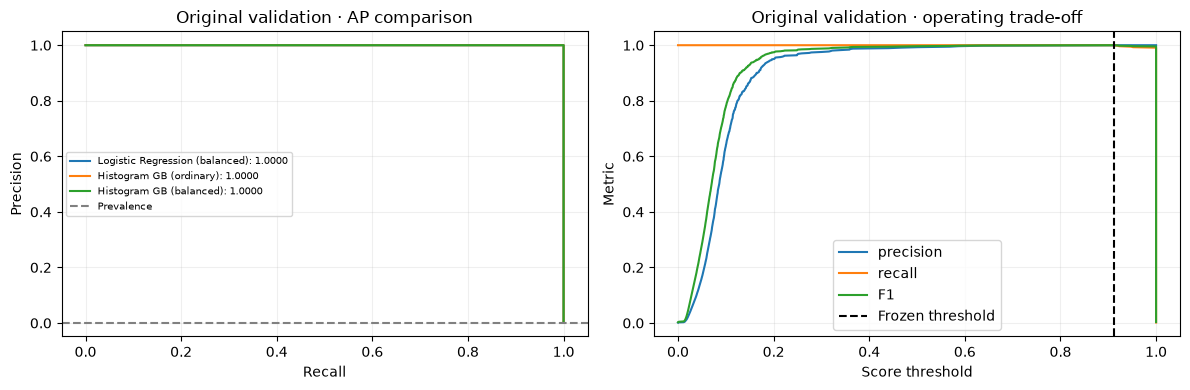

,feature,coefficient
2,log_amount_to_balance,-5.413381
4,amount_exceeds_balance,-0.333915
6,type_TRANSFER,0.321209
0,log_amount,1.070667
5,requests_full_balance,1.286210
1,log_opening_balance,3.406354
3,origin_balance_zero,10.583560


In [3]:
operating_points = pd.DataFrame([
    {'policy': name, **metrics(validation.isFraud, selected_validation_scores, threshold)}
    for name, threshold in [('Default 0.5 reference', 0.5), ('Frozen validation-F1 policy', fixed_threshold)]
])
display(operating_points.round(6))
save_table(operating_points, 'original_validation_operating_points')
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for name, scores in validation_scores.items():
    precision, recall, _ = precision_recall_curve(validation.isFraud, scores)
    ap = candidate_results.set_index('model').loc[name, 'AP']
    axes[0].plot(recall, precision, label=f'{name}: {ap:.4f}')
axes[0].axhline(validation.isFraud.mean(), linestyle='--', color='grey', label='Prevalence')
axes[0].set(xlabel='Recall', ylabel='Precision', title='Original validation · AP comparison')
axes[0].legend(fontsize=7)
for metric in ['precision', 'recall', 'F1']:
    axes[1].plot(threshold_table.threshold, threshold_table[metric], label=metric)
axes[1].axvline(fixed_threshold, linestyle='--', color='black', label='Frozen threshold')
axes[1].set(xlabel='Score threshold', ylabel='Metric', title='Original validation · operating trade-off')
axes[1].legend()
fig.tight_layout()
save_figure(fig, 'model_validation')
plt.show()

coefficients = pd.DataFrame({
    'feature': selected_model.named_steps['preprocess'].get_feature_names_out(),
    'coefficient': selected_model.named_steps['model'].coef_[0],
}).sort_values('coefficient')
display(coefficients)
save_table(coefficients, 'logistic_coefficients')

Coefficients describe conditional log-odds associations in the weighted Logistic Regression. Numeric coefficients are
per one training standard deviation; TRANSFER is relative to CASH_OUT. Correlated engineered features make individual
coefficients unsuitable for causal interpretation. The following ablations test predictive dependence more directly.

## Additional development evidence — feature ablation

Fit the same logistic and ordinary histogram-boosting specifications on steps 1–323, then evaluate on steps 324–377.
For each variant, choose its threshold on that validation window only. These are diagnostic development results,
not independently tested operating policies. The full-feature fits above are reused.

- **Full:** original inputs and engineered relationships.
- **No full-balance flag:** remove only the near-equality indicator; other relationships remain.
- **No explicit relationships:** retain log amount, log opening balance and the zero-balance indicator. A model may still
  infer relationships, particularly a non-linear model; this is not a complete removal of balance information.
- **Amount and type only:** remove the opening balance and every derivative of it. This is the conservative comparison
  motivated by the source warning. No version is scored on the historical test.

Development ablation: logistic, full


Development ablation: logistic, no_full_balance_flag


Development ablation: logistic, no_explicit_relationships


Development ablation: logistic, amount_and_type_only
Development ablation: hgb, full


Development ablation: hgb, no_full_balance_flag


Development ablation: hgb, no_explicit_relationships


Development ablation: hgb, amount_and_type_only


,model_kind,feature_set,training_transactions,training_fraud_prevalence,transactions,fraud_count,fraud_prevalence,precision,recall,F1,AP,threshold,alerts,alert_rate,TP,FP,FN,TN
0,logistic,full,1951895,0.001866,410437,560,0.001364,1.000000,1.000000,1.000000,1.000000,0.911739,560,0.001364,560,0,0,409877
1,logistic,no_full_balance_flag,1951895,0.001866,410437,560,0.001364,0.550968,0.762500,0.639700,0.672765,0.972324,775,0.001888,427,348,133,409529
2,logistic,no_explicit_relationships,1951895,0.001866,410437,560,0.001364,0.025919,0.303571,0.047760,0.018639,0.939596,6559,0.015981,170,6389,390,403488
3,logistic,amount_and_type_only,1951895,0.001866,410437,560,0.001364,0.007161,0.044643,0.012343,0.003317,0.862368,3491,0.008506,25,3466,535,406411
4,hgb,full,1951895,0.001866,410437,560,0.001364,1.000000,1.000000,1.000000,1.000000,0.980493,560,0.001364,560,0,0,409877
5,hgb,no_full_balance_flag,1951895,0.001866,410437,560,0.001364,0.814532,0.760714,0.786704,0.860549,0.403665,523,0.001274,426,97,134,409780
6,hgb,no_explicit_relationships,1951895,0.001866,410437,560,0.001364,0.584718,0.628571,0.605852,0.619634,0.187740,602,0.001467,352,250,208,409627
7,hgb,amount_and_type_only,1951895,0.001866,410437,560,0.001364,0.661871,0.164286,0.263233,0.165495,0.071473,139,0.000339,92,47,468,409830


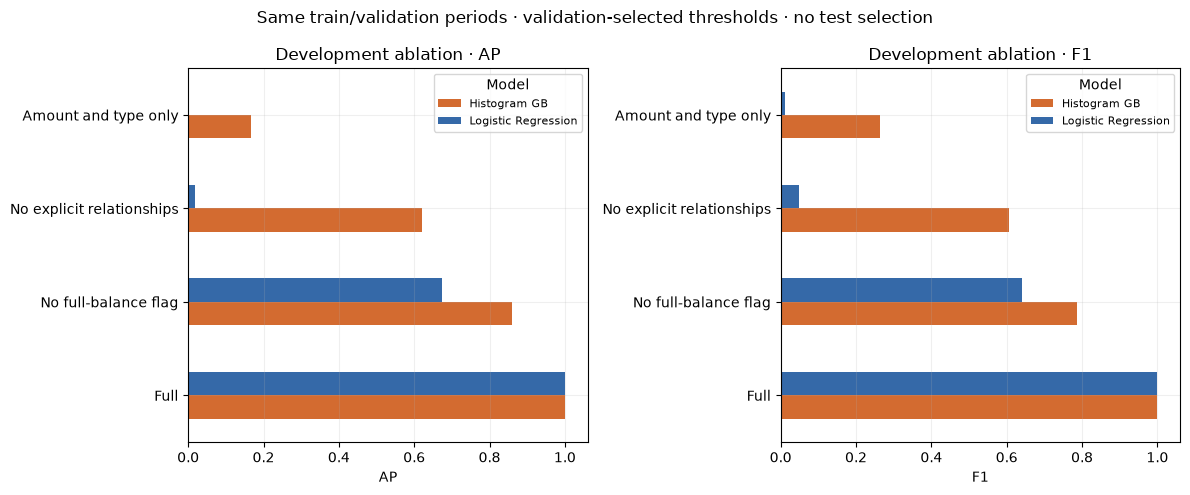

For Logistic Regression, validation AP is **1.0000** with the original features and **0.0033** with amount and type alone. Read the intermediate removals in the table: removing one indicator does not remove the information contained in the amount/balance relationship. A performance drop demonstrates dependence on these recorded fields; it does not prove the mechanism of contamination or establish causality. The source warning remains relevant even when no closing balance is read.

In [4]:
ablation_rows = []
for kind, full_name in [('logistic', 'Logistic Regression (balanced)'), ('hgb', 'Histogram GB (ordinary)')]:
    for feature_set in FEATURE_SETS:
        if feature_set == 'full':
            model, scores = candidates[full_name], validation_scores[full_name]
        else:
            model = fit_model(make_model(kind, feature_set), features_for(train, feature_set), train.isFraud)
            scores = score_model(model, validation, feature_set)
        threshold, _ = choose_threshold(validation.isFraud, scores)
        ablation_rows.append({'model_kind': kind, 'feature_set': feature_set,
                              'training_transactions': len(train), 'training_fraud_prevalence': train.isFraud.mean(),
                              **metrics(validation.isFraud, scores, threshold)})
        print(f'Development ablation: {kind}, {feature_set}')
ablation = pd.DataFrame(ablation_rows)
save_table(ablation, 'development_ablation')
display(ablation.round(6))

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
labels = ['Full', 'No full-balance flag', 'No explicit relationships', 'Amount and type only']
for ax, metric in zip(axes, ['AP', 'F1']):
    pivot = ablation.pivot(index='feature_set', columns='model_kind', values=metric).reindex(FEATURE_SETS)
    pivot.index = labels
    pivot.plot.barh(ax=ax, color=['#d36b30', '#3569a8'])
    ax.set(xlabel=metric, ylabel='', xlim=(0, 1.06), title=f'Development ablation · {metric}')
    ax.legend(title='Model', labels=['Histogram GB', 'Logistic Regression'], loc='upper right', fontsize=8)
fig.suptitle('Same train/validation periods · validation-selected thresholds · no test selection')
fig.tight_layout()
save_figure(fig, 'development_ablation')
plt.show()

full_ap = ablation.query("model_kind == 'logistic' and feature_set == 'full'").AP.iloc[0]
reduced_ap = ablation.query("model_kind == 'logistic' and feature_set == 'amount_and_type_only'").AP.iloc[0]
display(Markdown(
    f"For Logistic Regression, validation AP is **{full_ap:.4f}** with the original features and "
    f"**{reduced_ap:.4f}** with amount and type alone. Read the intermediate removals in the table: "
    "removing one indicator does not remove the information contained in the amount/balance relationship. "
    "A performance drop demonstrates dependence on these recorded fields; it does not prove the mechanism "
    "of contamination or establish causality. The source warning remains relevant even when no closing balance is read."
))

## Rolling temporal validation — development period only

Three fixed expanding-window checks use consecutive **fit → threshold selection → forward evaluation** windows.
Fit ends are 180, 240 and 300; threshold windows end at 216, 276 and 336; forward windows end at 252, 312 and 377.
All endpoints were specified before running these experiments and remain within the original development period.
Later fits can reuse earlier evaluation data, as in expanding-window validation; these checks are correlated, not three
independent test sets. There is no confirmation-delay gap because label timing is absent, a material limitation.

Compare the original logistic feature set with amount/type-only logistic and histogram boosting, using fixed settings.
Preprocessing and class weights use only each fit window; the threshold uses only the immediately following window.
Forward evaluation does not change that threshold. Report window-level results rather than selecting the best window.

Rolling window 1: logistic, full


Rolling window 1: logistic, amount_and_type_only


Rolling window 1: hgb, amount_and_type_only


Rolling window 2: logistic, full


Rolling window 2: logistic, amount_and_type_only


...

Rolling window 3: logistic, full


Rolling window 3: logistic, amount_and_type_only


Rolling window 3: hgb, amount_and_type_only


,fold,role,first_step,last_step,transactions,fraud_count,fraud_prevalence
0,1,Fit,1,180,895674,2046,0.002284
1,1,Threshold selection,181,216,330813,391,0.001182
2,1,Forward evaluation,217,252,227817,416,0.001826
3,2,Fit,1,240,1398317,2719,0.001944
4,2,Threshold selection,241,276,216994,412,0.001899
5,2,Forward evaluation,277,312,303112,390,0.001287
6,3,Fit,1,300,1780544,3401,0.001910
7,3,Threshold selection,301,336,310403,366,0.001179
8,3,Forward evaluation,337,377,271385,436,0.001607


,fold,model_kind,feature_set,fit_end,threshold_end,evaluation_end,transactions,fraud_count,fraud_prevalence,precision,recall,F1,AP,threshold,alerts,alert_rate,TP,FP,FN,TN
0,1,logistic,full,180,216,252,227817,416,0.001826,1.000000,0.992788,0.996381,0.992812,0.853367,413,0.001813,413,0,3,227401
1,1,logistic,amount_and_type_only,180,216,252,227817,416,0.001826,0.092784,0.064904,0.076379,0.045738,0.839610,291,0.001277,27,264,389,227137
2,1,hgb,amount_and_type_only,180,216,252,227817,416,0.001826,0.404372,0.177885,0.247078,0.152089,0.250453,183,0.000803,74,109,342,227292
3,2,logistic,full,240,276,312,303112,390,0.001287,1.000000,0.997436,0.998716,0.997442,0.870165,389,0.001283,389,0,1,302722
4,2,logistic,amount_and_type_only,240,276,312,303112,390,0.001287,0.003817,0.064103,0.007206,0.003237,0.849061,6549,0.021606,25,6524,365,296198
5,2,hgb,amount_and_type_only,240,276,312,303112,390,0.001287,0.804878,0.169231,0.279661,0.177786,0.072370,82,0.000271,66,16,324,302706
6,3,logistic,full,300,336,377,271385,436,0.001607,1.000000,0.997706,0.998852,1.000000,0.906728,435,0.001603,435,0,1,270949
7,3,logistic,amount_and_type_only,300,336,377,271385,436,0.001607,0.005615,0.697248,0.011140,0.005277,0.467918,54140,0.199495,304,53836,132,217113
8,3,hgb,amount_and_type_only,300,336,377,271385,436,0.001607,0.760870,0.160550,0.265152,0.174911,0.172895,92,0.000339,70,22,366,270927


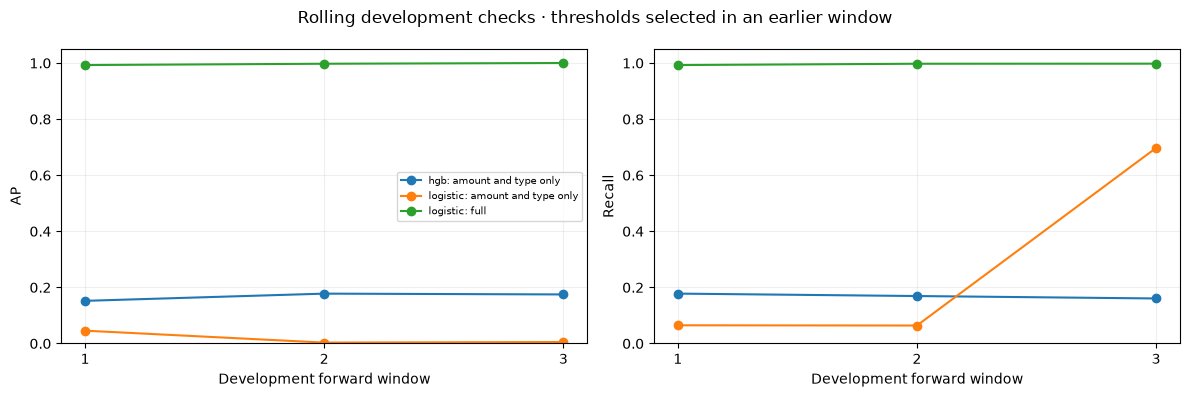

In [5]:
rolling_plan = [(180, 216, 252), (240, 276, 312), (300, 336, 377)]
rolling_specs = [('logistic', 'full'), ('logistic', 'amount_and_type_only'), ('hgb', 'amount_and_type_only')]
rolling_rows, window_rows = [], []
for fold, (fit_end, threshold_end, evaluation_end) in enumerate(rolling_plan, 1):
    fit_data, threshold_data, evaluation_data = time_windows(development, [0, fit_end, threshold_end, evaluation_end])
    assert evaluation_data.step.max() <= 377
    for role, frame in [('Fit', fit_data), ('Threshold selection', threshold_data), ('Forward evaluation', evaluation_data)]:
        window_rows.append({'fold': fold, 'role': role, 'first_step': int(frame.step.min()),
                            'last_step': int(frame.step.max()), 'transactions': len(frame),
                            'fraud_count': int(frame.isFraud.sum()), 'fraud_prevalence': frame.isFraud.mean()})
    for kind, feature_set in rolling_specs:
        model = fit_model(make_model(kind, feature_set), features_for(fit_data, feature_set), fit_data.isFraud)
        tuning_scores = score_model(model, threshold_data, feature_set)
        threshold, _ = choose_threshold(threshold_data.isFraud, tuning_scores)
        forward_scores = score_model(model, evaluation_data, feature_set)
        rolling_rows.append({'fold': fold, 'model_kind': kind, 'feature_set': feature_set,
                             'fit_end': fit_end, 'threshold_end': threshold_end, 'evaluation_end': evaluation_end,
                             **metrics(evaluation_data.isFraud, forward_scores, threshold)})
        print(f'Rolling window {fold}: {kind}, {feature_set}')
rolling = pd.DataFrame(rolling_rows)
rolling_windows = pd.DataFrame(window_rows)
save_table(rolling, 'development_rolling_results')
save_table(rolling_windows, 'development_rolling_windows')
display(rolling_windows.round(6))
display(rolling.round(6))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for (kind, feature_set), group in rolling.groupby(['model_kind', 'feature_set']):
    label = f'{kind}: {feature_set.replace("_", " ")}'
    axes[0].plot(group.fold, group.AP, marker='o', label=label)
    axes[1].plot(group.fold, group.recall, marker='o', label=label)
for ax, metric in zip(axes, ['AP', 'Recall']):
    ax.set(xlabel='Development forward window', ylabel=metric, xticks=[1, 2, 3], ylim=(0, 1.05))
axes[0].legend(fontsize=7)
fig.suptitle('Rolling development checks · thresholds selected in an earlier window')
fig.tight_layout()
save_figure(fig, 'development_rolling')
plt.show()

## Model Results — reproduction of the original frozen policy

Only the original Logistic Regression is evaluated below, with its original full feature set and recorded threshold.
The new ablations and rolling fits remain separate. This is the previously viewed historical test, not a newly sealed
holdout. One score vector is produced and reused for all historical diagnostics and monitoring exports.

,window,transactions,fraud_count,fraud_prevalence,precision,recall,F1,AP,threshold,alerts,alert_rate,TP,FP,FN,TN
0,Original validation (selection data),410437,560,0.001364,1.0,1.000000,1.000000,1.0,0.911739,560,0.001364,560,0,0,409877
1,Previously inspected historical test,408077,4010,0.009827,1.0,0.995511,0.997751,1.0,0.911739,3992,0.009782,3992,0,18,404067


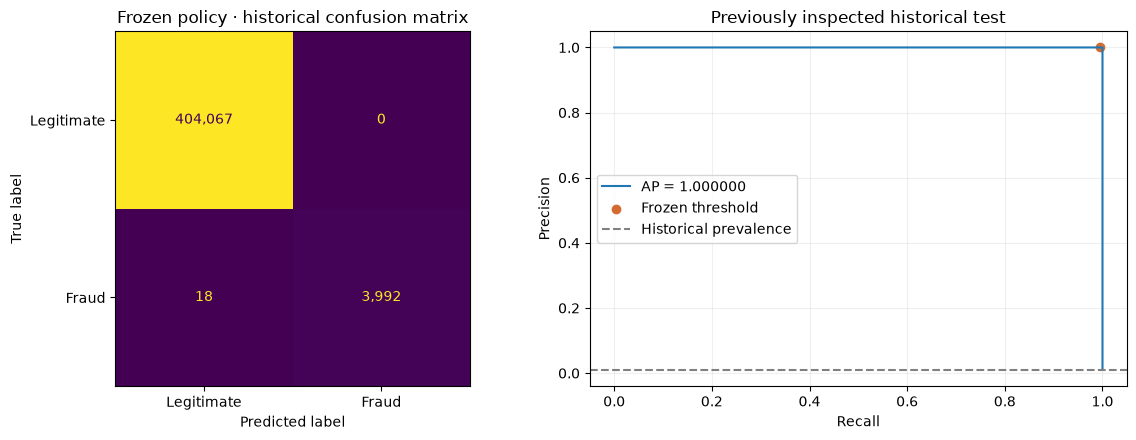

In [6]:
historical_scores = score_model(selected_model, historical_test)
historical_metrics = metrics(historical_test.isFraud, historical_scores, fixed_threshold)
for name, expected in frozen['expected_test_counts'].items():
    assert historical_metrics[name] == expected, f'Original {name} count did not reproduce.'
fixed_results = pd.DataFrame([
    {'window': 'Original validation (selection data)', **validation_metrics},
    {'window': 'Previously inspected historical test', **historical_metrics},
])
save_table(fixed_results, 'frozen_policy_results')
display(fixed_results.round(6))

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
ConfusionMatrixDisplay(confusion_matrix(historical_test.isFraud, historical_scores >= fixed_threshold, labels=[0, 1]),
                       display_labels=['Legitimate', 'Fraud']).plot(ax=axes[0], colorbar=False, values_format=',d')
axes[0].grid(False)
axes[0].set_title('Frozen policy · historical confusion matrix')
precision, recall, _ = precision_recall_curve(historical_test.isFraud, historical_scores)
axes[1].plot(recall, precision, label=f"AP = {historical_metrics['AP']:.6f}")
axes[1].scatter(historical_metrics['recall'], historical_metrics['precision'], color='#d36b30', label='Frozen threshold')
axes[1].axhline(historical_test.isFraud.mean(), color='grey', linestyle='--', label='Historical prevalence')
axes[1].set(xlabel='Recall', ylabel='Precision', title='Previously inspected historical test')
axes[1].legend()
fig.tight_layout()
save_figure(fig, 'frozen_policy_results')
plt.show()

## Why does fraud prevalence change?

This is a descriptive audit of the already-inspected historical window, not a basis for tuning.
Report fraud and legitimate counts per elapsed simulation step, type composition and within-type prevalence.
The late all-fraud tail is shown separately **as a coverage diagnostic**, without redefining the original result.
A simple standardisation asks what the historical-test prevalence would be with its observed type shares but the
validation window's within-type fraud rates. This is arithmetic decomposition, not a causal estimate.

,period,first_step,last_step,elapsed_steps,transactions,fraud_count,legitimate_count,fraud_prevalence,fraud_per_elapsed_step,legitimate_per_elapsed_step
0,Validation,324,377,54,410437,560,409877,0.001364,10.370370,7590.314815
1,Historical test: complete,378,743,366,408077,4010,404067,0.009827,10.956284,1104.008197
2,Historical test: through last legitimate step,378,718,341,407781,3714,404067,0.009108,10.891496,1184.947214
3,Historical test: later tail,719,743,25,296,296,0,1.000000,11.840000,0.000000


,period,type,transactions,share,fraud_count,fraud_prevalence
0,Validation,CASH_OUT,329968,0.803943,280,0.000849
1,Validation,TRANSFER,80469,0.196057,280,0.003480
2,Historical test,CASH_OUT,324885,0.796137,2005,0.006171
3,Historical test,TRANSFER,83192,0.203863,2005,0.024101


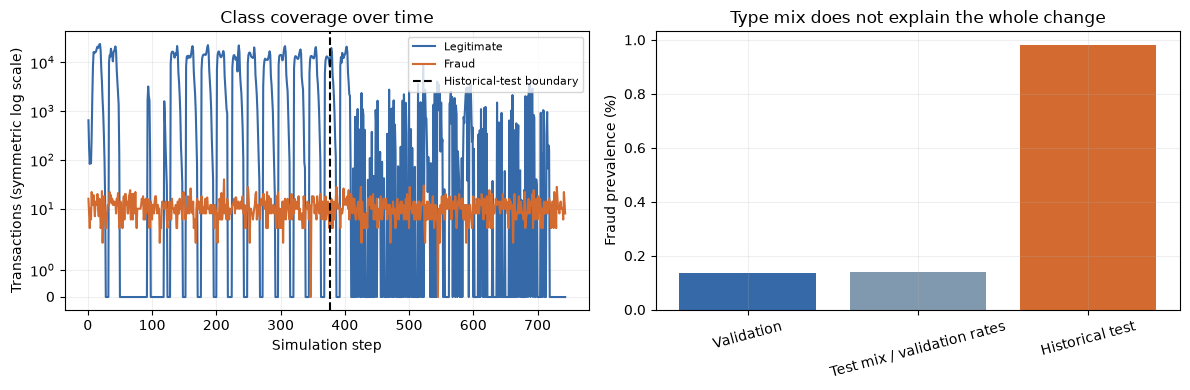

**Observed:** validation fraud prevalence is **0.1364%**, versus **0.9827%** in the historical test. The validation-rate/type-mix standardisation gives **0.1385%**. The tail after step 718 contains **296 transactions**, all labelled fraud. Even without this tail, historical-test prevalence is **0.9108%**, so the tail alone does not explain the gap. Use the elapsed-step count table to separate fraud arrival intensity from falling legitimate volume.

**Hypotheses, not established causes:** simulation schedules, the way the file was extracted, and separate fraud-injection behaviour could contribute to the late class coverage. This CSV has no run configuration or extraction log that establishes which explanation is correct. These patterns are not evidence of a real bank's risk trend.

In [7]:
last_legitimate_step = int(risk.loc[risk.isFraud.eq(0), 'step'].max())
coverage_rows = []
for name, frame in [('Validation', validation), ('Historical test: complete', historical_test),
                    ('Historical test: through last legitimate step', historical_test.loc[historical_test.step.le(last_legitimate_step)]),
                    ('Historical test: later tail', historical_test.loc[historical_test.step.gt(last_legitimate_step)])]:
    elapsed = int(frame.step.max() - frame.step.min() + 1)
    fraud_count = int(frame.isFraud.sum())
    coverage_rows.append({'period': name, 'first_step': int(frame.step.min()), 'last_step': int(frame.step.max()),
                          'elapsed_steps': elapsed, 'transactions': len(frame), 'fraud_count': fraud_count,
                          'legitimate_count': len(frame) - fraud_count, 'fraud_prevalence': frame.isFraud.mean(),
                          'fraud_per_elapsed_step': fraud_count / elapsed,
                          'legitimate_per_elapsed_step': (len(frame) - fraud_count) / elapsed})
coverage = pd.DataFrame(coverage_rows)
mix_rows = []
for name, frame in [('Validation', validation), ('Historical test', historical_test)]:
    for transaction_type, group in frame.groupby('type', observed=True):
        mix_rows.append({'period': name, 'type': transaction_type, 'transactions': len(group),
                         'share': len(group) / len(frame), 'fraud_count': int(group.isFraud.sum()),
                         'fraud_prevalence': group.isFraud.mean()})
mix = pd.DataFrame(mix_rows)
validation_type_rates = mix.query("period == 'Validation'").set_index('type').fraud_prevalence
historical_type_shares = mix.query("period == 'Historical test'").set_index('type').share
standardised_prevalence = float((validation_type_rates * historical_type_shares).sum())
save_table(coverage, 'temporal_class_coverage')
save_table(mix, 'temporal_type_mix')
display(coverage.round(6))
display(mix.round(6))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for label, colour in [(0, '#3569a8'), (1, '#d36b30')]:
    counts = risk.loc[risk.isFraud.eq(label)].groupby('step').size().reindex(range(1, 744), fill_value=0)
    axes[0].plot(counts.index, counts, color=colour, label='Fraud' if label else 'Legitimate')
axes[0].set(yscale='symlog', xlabel='Simulation step', ylabel='Transactions (symmetric log scale)', title='Class coverage over time')
axes[0].axvline(377.5, color='black', linestyle='--', label='Historical-test boundary')
axes[0].legend(fontsize=8)
axes[1].bar(['Validation', 'Test mix / validation rates', 'Historical test'],
            100 * np.array([validation.isFraud.mean(), standardised_prevalence, historical_test.isFraud.mean()]),
            color=['#3569a8', '#8199af', '#d36b30'])
axes[1].set(ylabel='Fraud prevalence (%)', title='Type mix does not explain the whole change')
axes[1].tick_params(axis='x', rotation=15)
fig.tight_layout()
save_figure(fig, 'temporal_prevalence_shift')
plt.show()

tail = coverage.iloc[-1]
without_tail = coverage.iloc[-2]
display(Markdown(
    f"**Observed:** validation fraud prevalence is **{validation.isFraud.mean():.4%}**, versus "
    f"**{historical_test.isFraud.mean():.4%}** in the historical test. The validation-rate/type-mix "
    f"standardisation gives **{standardised_prevalence:.4%}**. The tail after step {last_legitimate_step} "
    f"contains **{int(tail.transactions):,} transactions**, all labelled fraud. Even without this tail, "
    f"historical-test prevalence is **{without_tail.fraud_prevalence:.4%}**, so the tail alone does not explain the gap. "
    "Use the elapsed-step count table to separate fraud arrival intensity from falling legitimate volume.\n\n"
    "**Hypotheses, not established causes:** simulation schedules, the way the file was extracted, and separate "
    "fraud-injection behaviour could contribute to the late class coverage. This CSV has no run configuration or "
    "extraction log that establishes which explanation is correct. These patterns are not evidence of a real bank's risk trend."
))

## Business Interpretation

An alert is a referral for review or proportionate authentication, not proof of fraud or a mandate to block a payment.
False positives can delay legitimate payments, increase investigation workload and customer contacts, and damage trust.
False negatives leave labelled fraud undetected. A threshold chosen for F1 does not price these consequences.
The following figures refer only to eligible transactions in the previously inspected historical-test window.

In [8]:
m = historical_metrics
fraud_mask = historical_test.isFraud.eq(1).to_numpy()
alerts = historical_scores >= fixed_threshold
fraud_value = historical_test.loc[fraud_mask, 'amount'].sum()
missed_value = historical_test.loc[fraud_mask & ~alerts, 'amount'].sum()
operational = {
    'eligible_transactions': len(historical_test), 'alerts': m['alerts'],
    'alerts_per_10000_eligible': 10000 * m['alert_rate'],
    'false_alerts_per_10000_eligible': 10000 * m['FP'] / len(historical_test),
    'missed_fraud_per_10000_eligible': 10000 * m['FN'] / len(historical_test),
    'reviews_per_detected_fraud_transaction': m['alerts'] / m['TP'] if m['TP'] else None,
    'share_of_labelled_fraud_transaction_value_flagged': 1 - missed_value / fraud_value,
    'missed_fraud_transaction_value_dataset_currency_units': float(missed_value),
}
save_table(pd.DataFrame([operational]), 'frozen_policy_operations')
display(pd.Series(operational))
display(Markdown(
    f"The frozen policy generates **{m['alerts']:,} alerts**, or **{10000 * m['alert_rate']:.2f} per 10,000 eligible transactions**. "
    f"It flags **{m['FP']:,} legitimate transactions** and misses **{m['FN']:,} labelled fraud transactions** in this replay. "
    "Zero observed false alerts in a synthetic sample is not a guarantee of zero customer friction in live use. "
    "Labelled transaction value is not money saved or final loss; linked transfer/cash-out legs can double-count the same funds."
))

# Persist exactly these scores; Notebook 03 does not refit or rescore the policy.
replay_parts = []
for period, frame, scores in [('Development reference', validation, selected_validation_scores),
                               ('Historical replay', historical_test, historical_scores)]:
    part = frame[['step', 'type', 'amount', 'oldbalanceOrg', 'isFraud']].copy()
    part['score'] = scores
    part['alert'] = scores >= fixed_threshold
    part['period'] = period
    replay_parts.append(part)
replay = pd.concat(replay_parts).reset_index()
replay_path = ARTIFACTS / 'frozen_predictions.csv.gz'
replay.to_csv(replay_path, index=False, compression='gzip', float_format='%.17g')
joblib.dump(selected_model, ARTIFACTS / 'frozen_model.joblib')
export_manifest = {
    'data_sha256': frozen['data_sha256'], 'policy_sha256': file_sha256(ROOT / 'config' / 'frozen_policy.json'),
    'predictions_sha256': file_sha256(replay_path),
    'shared_code_sha256': file_sha256(ROOT / 'fraud_utils.py'),
    'model_sha256': file_sha256(ARTIFACTS / 'frozen_model.joblib'), 'rows': len(replay), 'threshold': fixed_threshold,
    'historical_counts': {name: m[name] for name in ['TP', 'FP', 'FN', 'TN']},
    'status': 'Previously inspected historical replay; opening-balance provenance unverified',
}
(ROOT / 'reports' / 'prediction_manifest.json').write_text(json.dumps(export_manifest, indent=2) + '\n')
(ROOT / 'reports' / 'model_summary.json').write_text(json.dumps({
    'selected_model': selected_name, 'threshold': fixed_threshold, 'validation': validation_metrics,
    'historical_test': historical_metrics, 'standardised_prevalence': standardised_prevalence,
    'operations': operational,
}, indent=2) + '\n')
print(f'Exported {len(replay):,} fixed-policy predictions for historical monitoring.')

eligible_transactions                                    4.080770e+05
alerts                                                   3.992000e+03
alerts_per_10000_eligible                                9.782468e+01
false_alerts_per_10000_eligible                          0.000000e+00
missed_fraud_per_10000_eligible                          4.410932e-01
reviews_per_detected_fraud_transaction                   1.000000e+00
share_of_labelled_fraud_transaction_value_flagged        9.936116e-01
missed_fraud_transaction_value_dataset_currency_units    4.039905e+07
dtype: float64

The frozen policy generates **3,992 alerts**, or **97.82 per 10,000 eligible transactions**. It flags **0 legitimate transactions** and misses **18 labelled fraud transactions** in this replay. Zero observed false alerts in a synthetic sample is not a guarantee of zero customer friction in live use. Labelled transaction value is not money saved or final loss; linked transfer/cash-out legs can double-count the same funds.

Exported 818,514 fixed-policy predictions for historical monitoring.


## Limitations

- The dataset is synthetic; balance provenance is explicitly in question. Code-level leakage checks cannot validate
  outcome-independent data generation. The balance-free experiments are development evidence, not deployment evidence.
- The original test has been viewed and EDA used the full dataset. No fresh independent holdout exists in this project.
  Rolling windows are overlapping development checks; they do not reset this history.
- All fits assume labels are available without delay. Related accounts and linked fraud legs can cross time boundaries.
  There are no event-disjoint checks, confirmation dates or independently verified losses.
- AP and precision depend on population composition. Small fraud counts and no confidence intervals limit precision of
  comparisons. Class-weighted scores are not calibrated probabilities; coefficient associations are not causal.
- F1 does not reflect investigation capacity or intervention costs. Counts are transactions, not customers or cases.

## Next Steps

Obtain independently collected future data and verified as-of feature contracts before evaluating any revised policy.
Use label-delay-aware backtesting and event/account dependence checks where identifiers and timestamps support them.
Agree review capacity, customer-friction constraints and loss definitions before changing the threshold. Calibrate on
separate development data only if probability estimates are required. Validate conclusions across simulation runs or
appropriate real data, and treat the monitoring notebook as a historical prototype rather than production readiness.